<a href="https://colab.research.google.com/github/fboldt/aulasann/blob/main/aula04d%20-%20XOR%20tanh.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

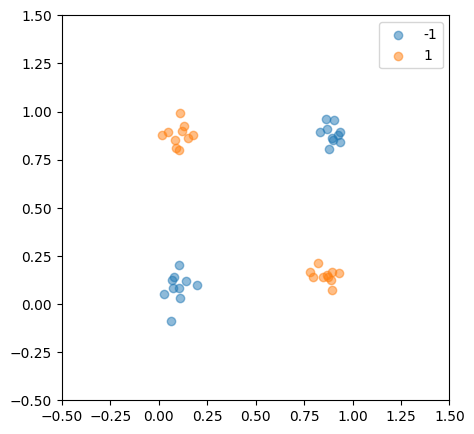

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def createLogicalDataset(n=40, func= lambda a, b: bool(a) != bool(b)):
  X, y = make_blobs(n_samples=n,
                    centers=[[0.1,0.1], [0.9, 0.1], [0.1, 0.9], [0.9, 0.9]],
                    n_features=2,
                    cluster_std=0.05,
                    center_box=(0,1))
  y = np.array([func(a>0.5, b>0.5) for a, b in X], dtype=int)*2-1
  return X, y

def plotDataset(X, y):
  plt.figure(figsize=(5,5))
  for i in sorted(list(set(y))):
    plt.scatter(X[y==i,0], X[y==i,1], label=f"{i}", alpha=0.5)
  plt.xlim(-0.5,1.5)
  plt.ylim(-0.5,1.5)
  plt.legend()

def plotHyperplan(vector, intercept, legend="hyperplan"):
    xs = np.array([0, 1])
    ys = -(vector[0] * xs + intercept) / vector[1]
    plt.plot(xs, ys, label=legend)
    plt.legend()

X, y = createLogicalDataset()
plotDataset(X, y)
plt.show()

Accuracy: 1.0


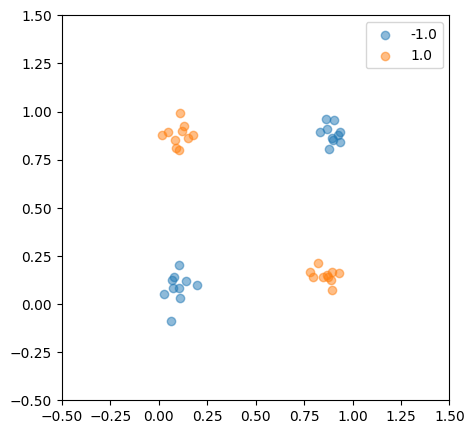

In [75]:
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.metrics import accuracy_score

def include_bias(X):
  return np.c_[np.ones(X.shape[0]), X]

class XORClassifer(BaseEstimator, ClassifierMixin):
  def __init__(self):
    self.ihw = np.array([[0.5, -1, 1], [0.5, 1, -1]]).T
    self.how = np.array([0.75, -0.9, -0.9])

  def fit(self, X, y):
    pass

  def predict(self, X):
    self.Xb = include_bias(X)
    self.pH = self.Xb @ self.ihw
    self.H = np.tanh(self.pH)
    self.Hb = include_bias(self.H)
    logits = self.Hb @ self.how
    y_pred = np.sign(logits)
    return y_pred


model = XORClassifer()
y_pred = model.predict(X)
print(f"Accuracy: {accuracy_score(y, y_pred)}")
plotDataset(X, y_pred)
plt.show()

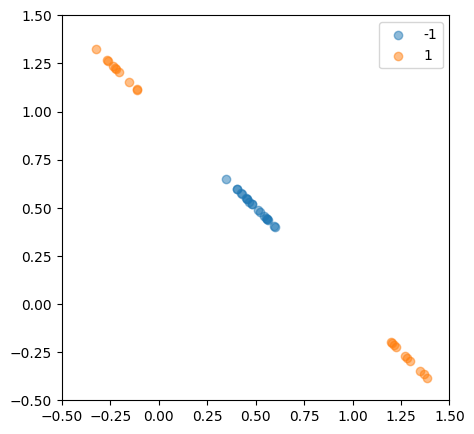

In [76]:
plotDataset(model.pH, y)
plt.show()

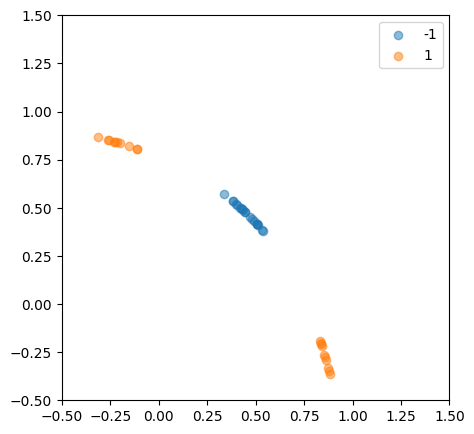

In [77]:
plotDataset(model.H, y)
plt.legend()
plt.show()

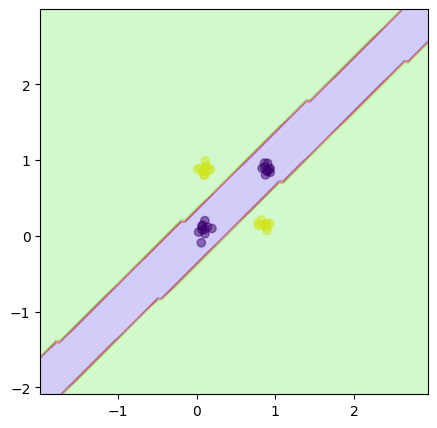

In [78]:
def defineAxes(X):
  offset = 2
  min1, max1 = X[:,0].min()-offset, X[:,0].max()+offset
  min2, max2 = X[:,1].min()-offset, X[:,1].max()+offset
  return [min1, max1, min2, max2]

def plotPredictions(model, X):
  axes = defineAxes(X)
  x0s = np.linspace(axes[0], axes[1], 100)
  x1s = np.linspace(axes[2], axes[3], 100)
  x0, x1 = np.meshgrid(x0s, x1s)
  X = np.c_[x0.ravel(), x1.ravel()]
  ypred = model.predict(X).reshape(x0.shape)
  plt.contourf(x0, x1, ypred, cmap=plt.cm.brg, alpha=0.2)

plt.figure(figsize=(5,5))
plt.scatter(X[:,0], X[:,1], c=y, alpha=0.5)
plotPredictions(model, X)
plt.show()